In [24]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
# Train test split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
# Save model
import joblib


In [25]:
# Load dataset

df = pd.read_csv('/content/diabetic_data[1].csv')

# Show first rows
print(df.head())

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

In [26]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Columns
print(df.columns)

# Data types
print(df.dtypes)

Dataset Shape: (101766, 50)
Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')
encounter_id                 int64
patien

In [27]:
#check missing value
print(df.isnull().sum())
#replace missing
df.replace('?', np.nan, inplace=True)
#missing value %
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.sort_values(ascending=False))
#drop weight column
df.drop('weight', axis=1, inplace=True)
#remove duplicates
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)
#handle missing value with mode
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

/tmp/ipykernel_20477/564796064.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   admission_type_id         101766 non-null  int64 
 6   discharge_disposition_id  101766 non-null  int64 
 7   admission_source_id       101766 non-null  int64 
 8   time_in_hospital          101766 non-null  int64 
 9   payer_code                101766 non-null  object
 10  medical_specialty         101766 non-null  object
 11  num_lab_procedures        101766 non-null  int64 
 12  num_procedures            101766 non-null  int64 
 13  num_medications           101766 non-null  int64 
 14  numb

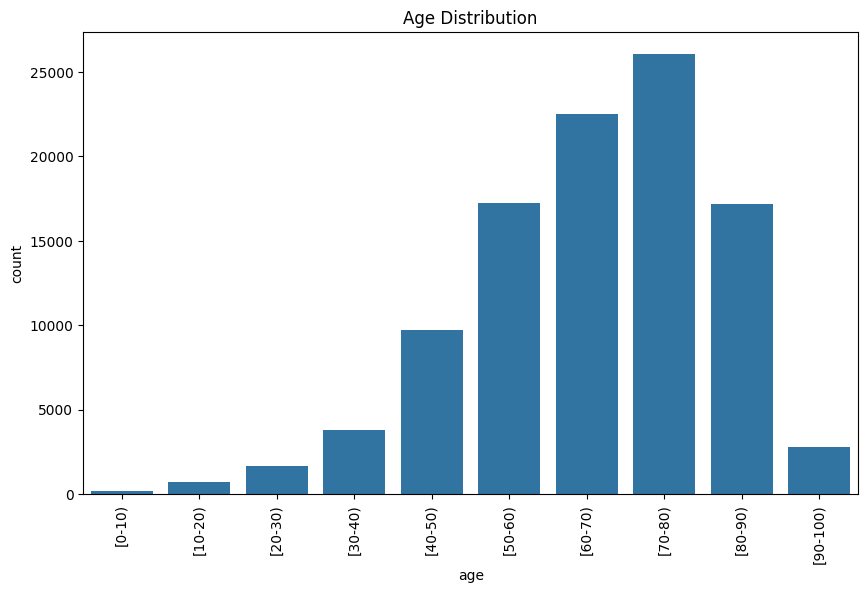

In [28]:
#EDA analysis

print(df.info())
#statstical analysis
print(df.describe())
#univerate analysis
#age
plt.figure(figsize=(10,6))
sns.countplot(x='age', data=df)
plt.xticks(rotation=90)
plt.title('Age Distribution')
plt.show()




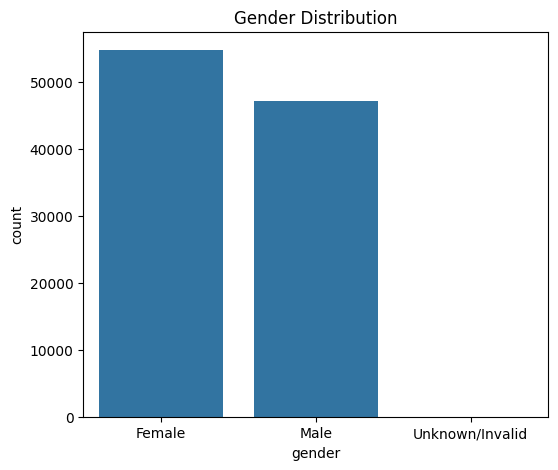

In [29]:
#gender
plt.figure(figsize=(6,5))
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.show()

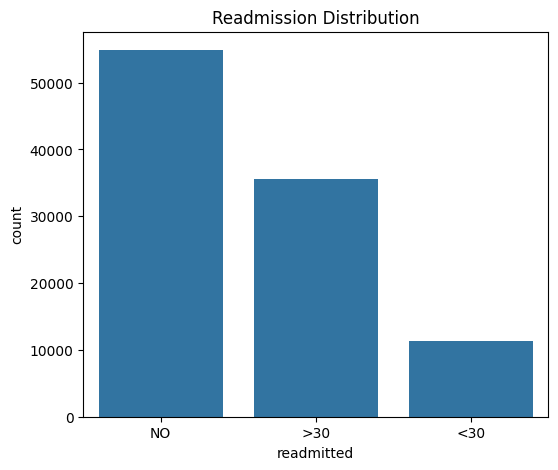

In [30]:
#readmission
plt.figure(figsize=(6,5))
sns.countplot(x='readmitted', data=df)
plt.title('Readmission Distribution')
plt.show()


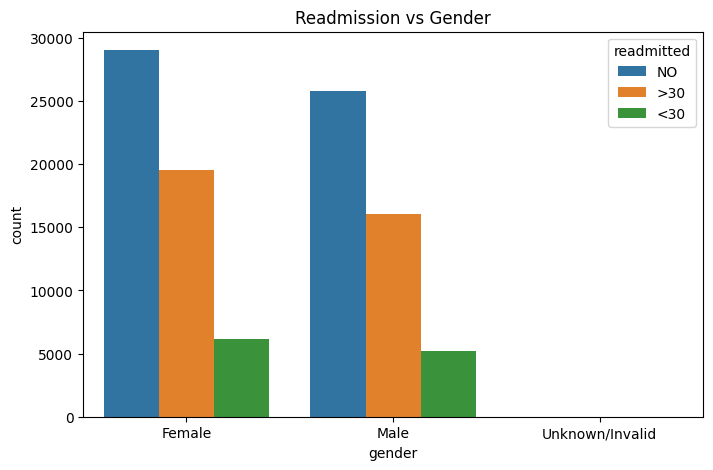

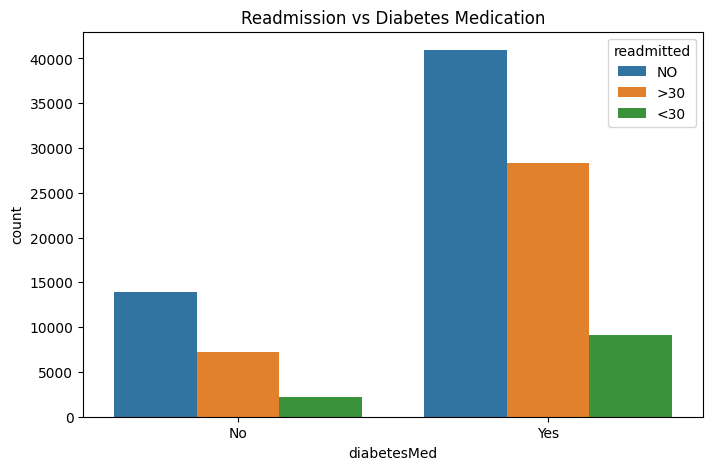

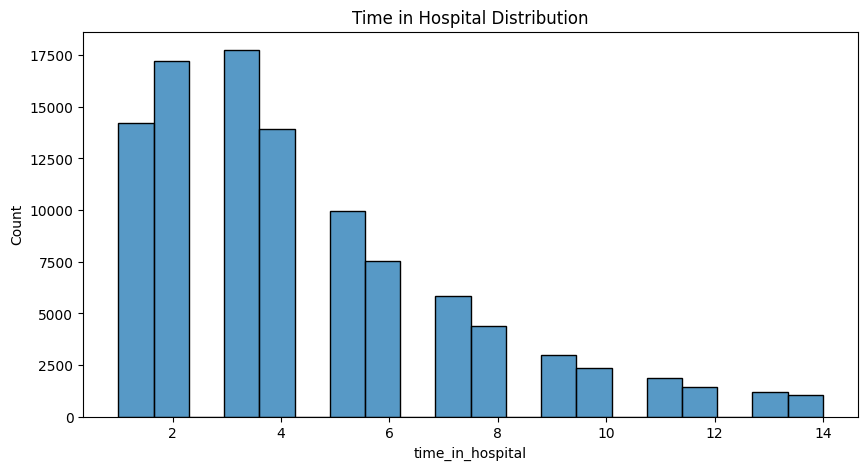

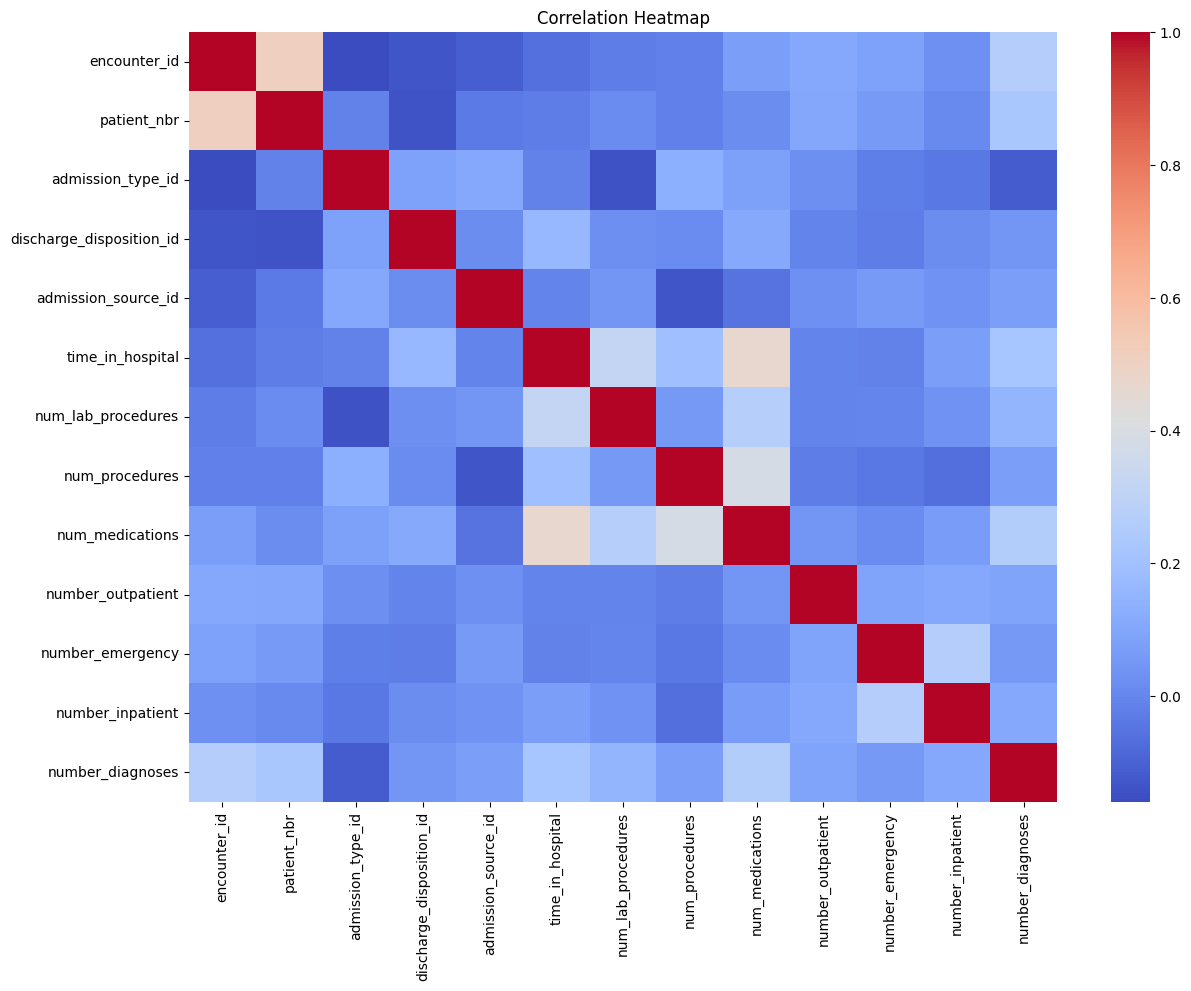

In [31]:
#Multiverate
#readmission vs gender
plt.figure(figsize=(8,5))
sns.countplot(x='gender', hue='readmitted', data=df)
plt.title('Readmission vs Gender')
plt.show()
#readmission vd disease medication
plt.figure(figsize=(8,5))
sns.countplot(x='diabetesMed', hue='readmitted', data=df)
plt.title('Readmission vs Diabetes Medication')
plt.show()
#time in hospital distrubution
plt.figure(figsize=(10,5))
sns.histplot(df['time_in_hospital'], bins=20)
plt.title('Time in Hospital Distribution')
plt.show()
#corrolation heat map
plt.figure(figsize=(14,10))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()



In [32]:
#feature engineering
#total visit
df['total_visits'] = (
    df['number_outpatient'] +
    df['number_emergency'] +
    df['number_inpatient']
)

print(df['total_visits'].head())
#feature selection
df.drop(['encounter_id', 'patient_nbr'], axis=1, inplace=True)

0    0
1    0
2    3
3    0
4    0
Name: total_visits, dtype: int64


In [33]:
#encode categorical
label_encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = label_encoder.fit_transform(df[col].astype(str))


In [36]:
#define feature
X = df.drop('readmitted', axis=1)
y = df['readmitted']
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
#feature scalling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
#logistic regression
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_log, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_log, average='weighted'))

Accuracy: 0.569519504765648
Precision: 0.5345234170631823
Recall: 0.569519504765648
F1 Score: 0.4980277816702337


In [39]:
#Decision tree
DT = DecisionTreeClassifier(random_state=42)

DT.fit(X_train, y_train)

y_pred_dt = DT.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_dt, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_dt, average='weighted'))

Accuracy: 0.47499263044119094
Precision: 0.476153603787223
Recall: 0.47499263044119094
F1 Score: 0.4755685192151777


In [40]:
#random forest
RF = RandomForestClassifier(random_state=42)

RF.fit(X_train, y_train)

y_pred_rf = RF.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_rf, average='weighted'))

Accuracy: 0.580573842979267
Precision: 0.5509827925348204
Recall: 0.580573842979267
F1 Score: 0.5338232670916423


In [41]:
#compare algorithm
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

comparison = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

print(comparison)


                 Model  Accuracy
0  Logistic Regression  0.569520
1        Decision Tree  0.474993
2        Random Forest  0.580574


In [42]:
#hyperparameter tuning
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}


grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)


grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 150}
Best Score: 0.5872720960954402


In [43]:
best_model = grid_search.best_estimator_

best_predictions = best_model.predict(X_test)
print(classification_report(y_test, best_predictions))

              precision    recall  f1-score   support

           0       0.46      0.01      0.02      2285
           1       0.51      0.37      0.43      7117
           2       0.62      0.85      0.71     10952

    accuracy                           0.59     20354
   macro avg       0.53      0.41      0.39     20354
weighted avg       0.56      0.59      0.54     20354



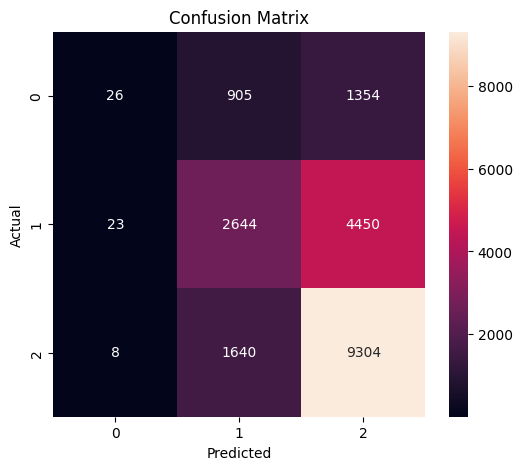

In [44]:
#confusion
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [45]:
joblib.dump(best_model, 'diabetesss_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('Model and scaler saved successfully!')

Model and scaler saved successfully!


In [46]:
!pip install streamlit pyngrok joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 53.0 MB/s eta 0:00:00


In [ ]:
import joblib

joblib.dump(best_model, '/content/diabetesss_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully!")

In [47]:
%%writefile app.py

import streamlit as st

st.title("My First Streamlit App")
st.write("Hello World!")
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("diabetesss_model.pkl")
scaler = joblib.load("scaler.pkl")

st.title("Diabetes Readmission Prediction")

time_in_hospital = st.number_input("Time in Hospital", 1, 20, 5)
num_lab_procedures = st.number_input("Lab Procedures", 0, 150, 40)
num_procedures = st.number_input("Procedures", 0, 20, 2)
num_medications = st.number_input("Medications", 0, 100, 10)
number_outpatient = st.number_input("Outpatient Visits", 0, 20, 0)
number_emergency = st.number_input("Emergency Visits", 0, 20, 0)
number_inpatient = st.number_input("Inpatient Visits", 0, 20, 0)

if st.button("Predict"):

    total_visits = (
        number_outpatient +
        number_emergency +
        number_inpatient
    )

    data = pd.DataFrame({
        "time_in_hospital":[time_in_hospital],
        "num_lab_procedures":[num_lab_procedures],
        "num_procedures":[num_procedures],
        "num_medications":[num_medications],
        "number_outpatient":[number_outpatient],
        "number_emergency":[number_emergency],
        "number_inpatient":[number_inpatient],
        "total_visits":[total_visits]
    })

    data = scaler.transform(data)

    prediction = model.predict(data)

    st.success(f"Prediction = {prediction[0]}")

Writing app.py


In [48]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib

Writing requirements.txt


In [49]:
import os

print(os.listdir())

['.config', 'scaler.pkl', 'diabetic_data[1].csv', 'app.py', 'requirements.txt', 'diabetesss_model.pkl', 'sample_data']


In [50]:
from google.colab import files

files.download("app.py")
files.download("requirements.txt")
files.download("diabetesss_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>